# Exercise 1 — Logistic Regression

## Part A: Understanding Logistic Regression

Imagine we want to predict whether a student will pass an exam.

For each student, we know:

* the number of study hours
* whether the student passed or failed

Our goal is to predict: `pass (1) or fail (0)`

Unlike linear regression, logistic regression predicts a probability between 0 and 1.

### Logistic Regression Model

The model is:

`z = weight × x + bias`

Then we apply the sigmoid function:

`p = 1 / (1 + e^(-z))`

Where:

* x = input feature (study hours)
* weight = importance of the feature
* bias = shifts the curve
* p = probability of passing

### Decision Rule

After computing the probability:

`if p > 0.5 → predict PASS

else → predict FAIL`

Your Task

Change the values of: `weight` and `bias` as in previous exercises.

until the sigmoid curve separates the two classes as well as possible.

Try to understand:

* what the weight changes
* what the bias changes
* where the decision boundary appears

### Sample Student Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# x = study hours
x = np.array([0,1,2,3,4,5,6,7,8,9])

# y = fail(0) or pass(1)
y = np.array([0,0,0,0,0,1,1,1,1,1])

In [5]:
weight = 10 
bias = -45

### Logistic Regression Predictions

In [3]:
# Linear part
z = weight * x + bias

# Sigmoid
p = 1 / (1 + np.exp(-z))

# Predicted classes
y_pred = (p > 0.5).astype(int)

### Plot the model

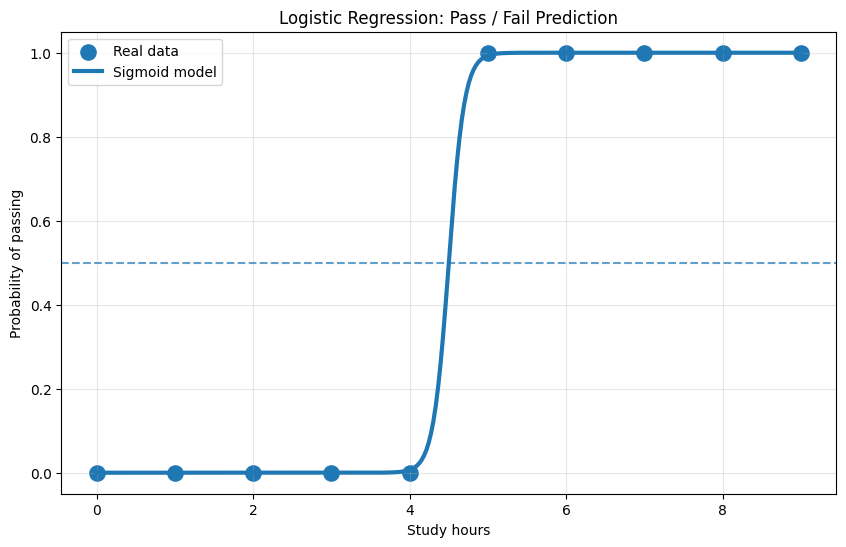

In [6]:
plt.figure(figsize=(10,6))

# Real data
plt.scatter(x, y, s=120, label="Real data")

# Smooth sigmoid curve
x_curve = np.linspace(0, 9, 300)
z_curve = weight * x_curve + bias
p_curve = 1 / (1 + np.exp(-z_curve))

plt.plot(x_curve, p_curve, linewidth=3, label="Sigmoid model")

# Decision threshold
plt.axhline(0.5, linestyle="--", alpha=0.7)

plt.xlabel("Study hours")
plt.ylabel("Probability of passing")
plt.title("Logistic Regression: Pass / Fail Prediction")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

Questions

1. What does the weight control? Weight is steepness and confidence of the curve
2. What does the bias control? Bias is horizontal position of the boundary 
3. What happens when the sigmoid becomes steeper? Steeper sigmoid is model is more decisive and less ambiguous zone
4. Where is the decision boundary? Decision boundary is at −bias and weight ≈ 4.67 hours with defaults
5. Which students are difficult to classify? Students near the boundary, around 4.5 hours are hardest to classify
6. Why is logistic regression better than linear regression here? Logistic regression outputs a valid probability,
while linear regression can give values outside that range and doesn't have a natural threshold

## Part B — Use a Real Dataset

Now repeat the same process using a real dataset.

Choose:

- one numerical column as `x`
- one binary column as `y`

Below are beginner-friendly datasets you can use.

| Dataset | Link | Example `x` | Example `y` | Task |
|---|---|---|---|---|
| Titanic | [Open dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv) | `Age`, `Fare` | `Survived` | Predict survival |
| Breast Cancer Wisconsin | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | `mean radius`, `mean texture` | `target` | Benign vs malignant |
| Heart Disease | [Open dataset](https://archive.ics.uci.edu/dataset/45/heart+disease) | `cholesterol`, `age` | `disease` | Predict heart disease |
| Palmer Penguins | [Open dataset](https://github.com/allisonhorst/palmerpenguins) | `bill_length_mm`, `body_mass_g` | species converted to binary | Classify penguin species |
| Student Performance | [Open dataset](https://archive.ics.uci.edu/dataset/320/student+performance) | `studytime`, `absences` | pass/fail from final grade | Predict pass/fail |
| SMS Spam | [Open dataset](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) | message length, number of keywords | spam / ham | Spam detection |

### Suggested choice 

Use the **Titanic dataset** first:

In [8]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Your Real-Data Task

1. Load the dataset.
2. Display the first rows with df.head().
3. Choose one feature x.
4. Choose one binary target y.
5. Plot the data.
6. Try different values of weight and bias.
7. Observe how the sigmoid changes.
8. Compare your intuition with Python’s logistic regression model.

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g     sex  year
0  Adelie  Torgersen            39.1           18.7              181.0       3750.0    male  2007
1  Adelie  Torgersen            39.5           17.4              186.0       3800.0  female  2007
2  Adelie  Torgersen            40.3           18.0              195.0       3250.0  female  2007
3  Adelie  Torgersen             NaN            NaN                NaN          NaN     NaN  2007
4  Adelie  Torgersen            36.7           19.3              193.0       3450.0  female  2007
5  Adelie  Torgersen            39.3           20.6              190.0       3650.0    male  2007
6  Adelie  Torgersen            38.9           17.8              181.0       3625.0  female  2007
7  Adelie  Torgersen            39.2           19.6              195.0       4675.0    male  2007
8  Adelie  Torgersen            34.1           18.1              193.0       3475.0     NaN  2007
9  Adelie  Torgersen

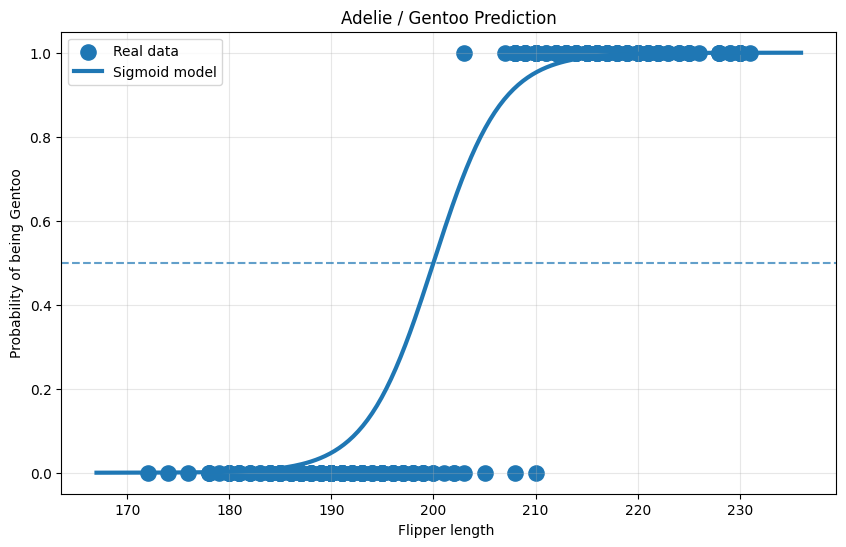

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"
df = pd.read_csv(url)
df2 = df[df['species'].isin(['Adelie', 'Gentoo'])].dropna(subset=['flipper_length_mm'])

x = df2['flipper_length_mm'].values
y = (df2['species'] == 'Gentoo').astype(int).values

print(df.head(10).to_string(index=True))

weight = 0.3
bias   = -60
z = weight * x + bias

p = 1 / (1 + np.exp(-z))

y_pred = (p > 0.5).astype(int)
acc = (y_pred == y).mean() * 100

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=120, label="Real data")

x_curve = np.linspace(x.min() - 5, x.max() + 5, 300)
p_curve = 1 / (1 + np.exp(-(weight * x_curve + bias)))

plt.plot(x_curve, p_curve, linewidth=3, label="Sigmoid model")
plt.axhline(0.5, linestyle="--", alpha=0.7)
plt.xlabel("Flipper length ")
plt.ylabel("Probability of being Gentoo")
plt.title("Adelie / Gentoo Prediction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
The perfect weight and bias
weight = 0.3
bias   = -60

In [20]:
acc

np.float64(60.21897810218978)